# AC-2 – Parte 1: PSO (Particle Swarm Optimization)


Resumo do cenário: uma empresa de logística quer descobrir onde colocar 5 centros de distribuição pra atender 50 clientes gastando o menos possível com entrega. Como as coordenadas dos centros são variáveis contínuas e o espaço de busca é grande, o professor pediu pra gente resolver isso com PSO.

As 4 missões abaixo vão nessa ordem: primeiro uma partícula sozinha (pra entender a fórmula), depois um enxame pequeno numa função clássica (Rosenbrock), depois o problema real da logística, e por fim uns testes trocando os parâmetros do PSO.

In [ ]:
%matplotlib inline

## Missão 1 – A Partícula Solitária

Objetivo: entender como uma única partícula se move, sem enxame ainda. Ela procura o mínimo de f(x) = x², que já sabemos que é x = 0.

 PARTÍCULA SOLITÁRIA PROcurando o MÍNIMO

Posição inicial: -8.0733
Fitness inicial: 65.1779

Iteração  1: pos = -8.0296, fitness =  64.4749
Iteração  2: pos = -7.9947, fitness =  63.9153
Iteração  3: pos = -7.9668, fitness =  63.4694
Iteração  4: pos = -7.9444, fitness =  63.1138
Iteração  5: pos = -7.9265, fitness =  62.8300
Iteração  6: pos = -7.9122, fitness =  62.6034
Iteração  7: pos = -7.9008, fitness =  62.4225
Iteração  8: pos = -7.8916, fitness =  62.2779
Iteração  9: pos = -7.8843, fitness =  62.1624
Iteração 10: pos = -7.8785, fitness =  62.0700
Iteração 11: pos = -7.8738, fitness =  61.9962
Iteração 12: pos = -7.8700, fitness =  61.9371
Iteração 13: pos = -7.8670, fitness =  61.8899
Iteração 14: pos = -7.8646, fitness =  61.8522
Iteração 15: pos = -7.8627, fitness =  61.8220
Iteração 16: pos = -7.8612, fitness =  61.7978
Iteração 17: pos = -7.8599, fitness =  61.7785
Iteração 18: pos = -7.8589, fitness =  61.7631
Iteração 19: pos = -7.8582, fitness =  61.7507
Iteração 20: p

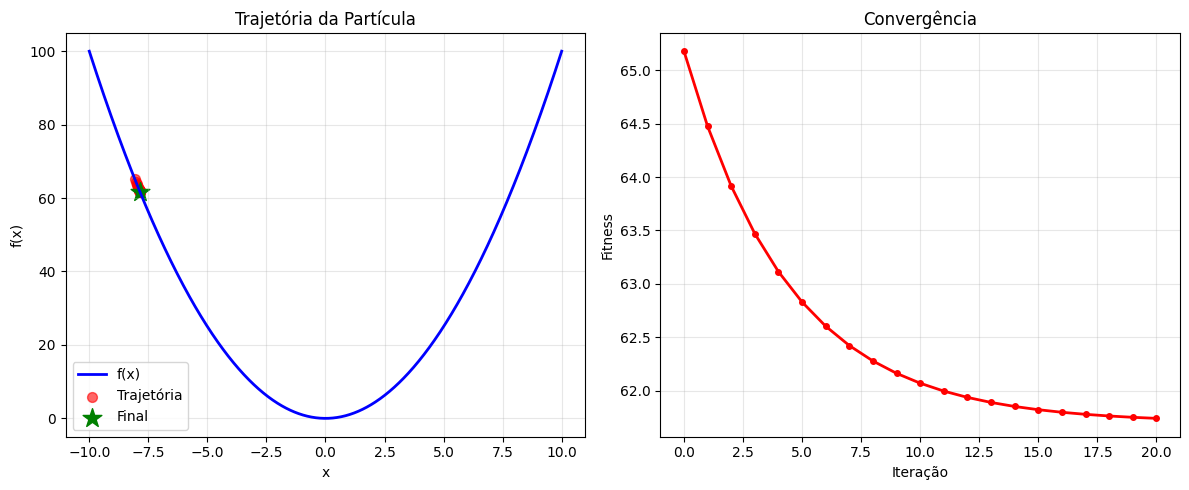

In [ ]:
"""
MISSÃO 1: A PARTÍCULA SOLITÁRIA
Cenário: Uma partícula procurando o mínimo de f(x) = x²
Domínio: x ∈ [-10, 10]
"""

import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import time

# ==================== CONFIGURAÇÕES ====================
ITERACOES = 20
W = 0.8
C1 = 1.5
C2 = 1.5
LIMITE = 10

# ==================== FUNÇÃO OBJETIVO ====================
def funcao(x):
    return x**2  # Mínimo em x=0

# ==================== PSO UMA PARTÍCULA ====================
# Inicializar
posicao = random.uniform(-LIMITE, LIMITE)
velocidade = random.uniform(-1, 1)
fitness = funcao(posicao)

pBest_pos = posicao
pBest_fit = fitness

# gBest é o mesmo que pBest (só uma partícula)
gBest_pos = posicao
gBest_fit = fitness

historico_pos = [posicao]
historico_fit = [fitness]

print("=" * 60)
print(" PARTÍCULA SOLITÁRIA PROcurando o MÍNIMO")
print("=" * 60)
print(f"\nPosição inicial: {posicao:.4f}")
print(f"Fitness inicial: {fitness:.4f}\n")

for i in range(ITERACOES):
    # TODO 1: Atualizar velocidade
    r1 = random.random()
    r2 = random.random()

    # Fórmula: v_novo = w * v_atual + c1 * r1 * (pBest - pos) + c2 * r2 * (gBest - pos)
    velocidade_nova = W * velocidade + C1 * r1 * (pBest_pos - posicao) + C2 * r2 * (gBest_pos - posicao)

    # TODO 2: Atualizar posição
    # Fórmula: pos_nova = pos_atual + v_novo
    posicao_nova = posicao + velocidade_nova

    # Garantir limites
    posicao_nova = np.clip(posicao_nova, -LIMITE, LIMITE)

    # Avaliar
    fitness_novo = funcao(posicao_nova)

    # Atualizar variáveis
    posicao = posicao_nova
    velocidade = velocidade_nova
    fitness = fitness_novo

    # Atualizar pBest
    if fitness < pBest_fit:
        pBest_fit = fitness
        pBest_pos = posicao

    # Atualizar gBest (mesmo que pBest, só uma partícula)
    if fitness < gBest_fit:
        gBest_fit = fitness
        gBest_pos = posicao

    # Guardar histórico
    historico_pos.append(posicao)
    historico_fit.append(fitness)

    # Mostrar progresso
    print(f"Iteração {i+1:2d}: pos = {posicao:7.4f}, fitness = {fitness:8.4f}")

print("\n" + "=" * 60)
print(" RESULTADO FINAL")
print("=" * 60)
print(f"Posição final: {posicao:.6f}")
print(f"Fitness final: {fitness:.6f}")
print(f"Ótimo global: x = 0.000000, f(x) = 0.000000")
print(f"Erro: {abs(posicao):.6f}")

# Visualizar
x_plot = np.linspace(-LIMITE, LIMITE, 1000)
y_plot = funcao(x_plot)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.scatter(historico_pos, [funcao(p) for p in historico_pos],
            color='red', s=50, alpha=0.6, label='Trajetória')
plt.scatter(posicao, fitness, color='green', s=200, marker='*', label='Final')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trajetória da Partícula')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(ITERACOES+1), historico_fit, 'r-o', linewidth=2, markersize=4)
plt.xlabel('Iteração')
plt.ylabel('Fitness')
plt.title('Convergência')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Missão 2 – O Enxame de Partículas

Objetivo: trocar 1 partícula por 20 e ver a cooperação funcionando. Dessa vez o alvo é a função de Rosenbrock, que tem um "vale" bem mais difícil de navegar que a parábola da Missão 1. O mínimo é em (1, 1).

 PSO - FUNÇÃO DE ROSENBROCK
Início: Melhor fitness = 4.292588
Iteração  10: Melhor = 0.227327
Iteração  20: Melhor = 0.032176
Iteração  30: Melhor = 0.018403
Iteração  40: Melhor = 0.002760
Iteração  50: Melhor = 0.002760

Fim: Melhor fitness = 0.002760
Ótimo global: f(1,1) = 0.000000


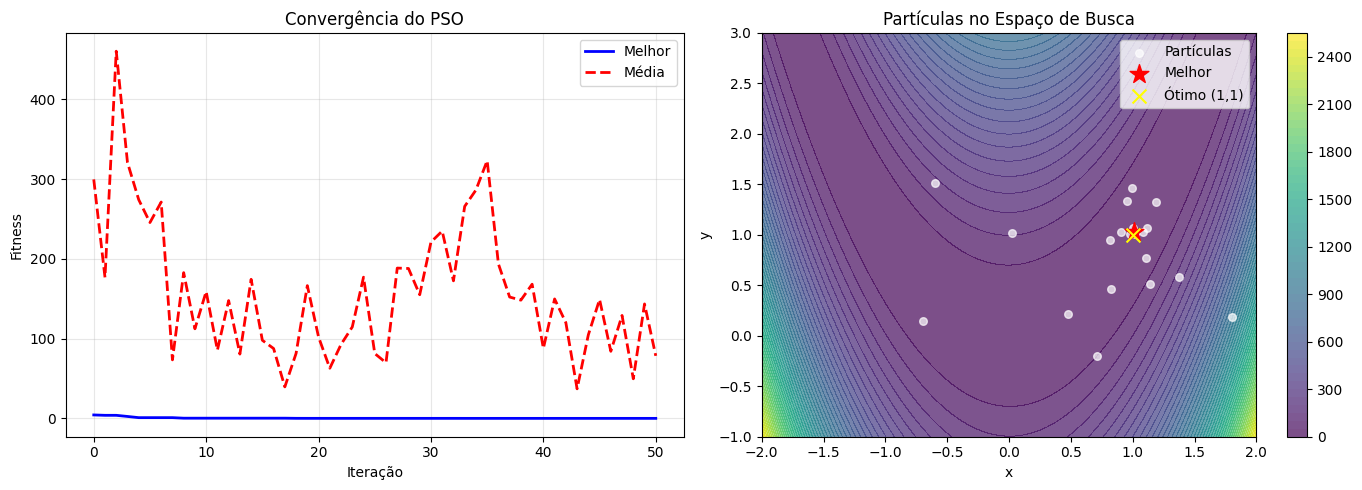

In [ ]:
"""
MISSÃO 2: O ENXAME DE PARTÍCULAS
Cenário: Enxame procurando o mínimo da função de Rosenbrock
f(x,y) = (1-x)² + 100*(y-x²)²
"""

import numpy as np
import matplotlib.pyplot as plt
import random

# ==================== CONFIGURAÇÕES ====================
NUM_PARTICULAS = 20
ITERACOES = 50
W = 0.7
C1 = 1.8
C2 = 1.8
X_MIN, X_MAX = -2, 2
Y_MIN, Y_MAX = -1, 3

# ==================== FUNÇÃO OBJETIVO ====================
def rosenbrock(posicao):
    x, y = posicao
    return (1 - x)**2 + 100 * (y - x**2)**2

# ==================== FUNÇÕES A COMPLETAR ====================

# TODO 1: Inicializar uma partícula
def criar_particula():
    """
    Cria uma partícula com posição e velocidade aleatórias.

    Retorna um dicionário com:
    - posicao: array [x, y] aleatório dentro dos limites
    - velocidade: array [vx, vy] aleatório entre -0.5 e 0.5
    - fitness: fitness na posição atual
    - pBest_pos: cópia da posição inicial
    - pBest_fit: fitness inicial
    """
    x = random.uniform(X_MIN, X_MAX)
    y = random.uniform(Y_MIN, Y_MAX)
    posicao = np.array([x, y])
    velocidade = np.random.uniform(-0.5, 0.5, 2)
    fit = rosenbrock(posicao)

    particula = {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }
    return particula

# TODO 2: Atualizar a velocidade de uma partícula
def atualizar_velocidade(particula, gBest_pos):
    """
    Atualiza a velocidade da partícula usando a fórmula do PSO.

    Parâmetros:
    - particula: dicionário da partícula
    - gBest_pos: melhor posição global

    Retorna: nova velocidade (array)
    """
    r1 = np.random.random(2)
    r2 = np.random.random(2)

    # Fórmula: v_novo = w*v + c1*r1*(pBest - pos) + c2*r2*(gBest - pos)
    nova_velocidade = (W * particula['velocidade']
                        + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
                        + C2 * r2 * (gBest_pos - particula['posicao']))
    return nova_velocidade

# TODO 3: Atualizar a posição de uma partícula
def atualizar_posicao(particula):
    """
    Atualiza a posição da partícula baseado na sua velocidade.
    Garante que a posição fique dentro dos limites.
    """
    nova_posicao = particula['posicao'] + particula['velocidade']
    nova_posicao[0] = np.clip(nova_posicao[0], X_MIN, X_MAX)
    nova_posicao[1] = np.clip(nova_posicao[1], Y_MIN, Y_MAX)
    return nova_posicao

# ==================== CÓDIGO PRONTO ====================

def executar_pso():
    # Inicializar enxame
    enxame = []
    for _ in range(NUM_PARTICULAS):
        enxame.append(criar_particula())

    # Encontrar gBest inicial
    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = {'melhor': [gBest_fit], 'media': [np.mean([p['fitness'] for p in enxame])]}

    print("=" * 60)
    print(" PSO - FUNÇÃO DE ROSENBROCK")
    print("=" * 60)
    print(f"Início: Melhor fitness = {gBest_fit:.6f}")

    for iteracao in range(ITERACOES):
        # Atualizar todas as partículas
        for p in enxame:
            # Atualizar velocidade e posição
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)

            # Avaliar nova posição
            p['fitness'] = rosenbrock(p['posicao'])

            # Atualizar pBest
            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            # Atualizar gBest
            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico['melhor'].append(gBest_fit)
        historico['media'].append(np.mean([p['fitness'] for p in enxame]))

        if (iteracao + 1) % 10 == 0:
            print(f"Iteração {iteracao+1:3d}: Melhor = {gBest_fit:.6f}")

    print(f"\nFim: Melhor fitness = {gBest_fit:.6f}")
    print(f"Ótimo global: f(1,1) = 0.000000")

    return gBest_pos, gBest_fit, historico, enxame

# ==================== EXECUTAR ====================
best_pos, best_fit, historico, enxame = executar_pso()

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historico['melhor'], 'b-', linewidth=2, label='Melhor')
ax1.plot(historico['media'], 'r--', linewidth=2, label='Média')
ax1.set_xlabel('Iteração')
ax1.set_ylabel('Fitness')
ax1.set_title('Convergência do PSO')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mostrar partículas
x_pos = [p['posicao'][0] for p in enxame]
y_pos = [p['posicao'][1] for p in enxame]

x_plot = np.linspace(X_MIN, X_MAX, 100)
y_plot = np.linspace(Y_MIN, Y_MAX, 100)
X, Y = np.meshgrid(x_plot, y_plot)
Z = np.array([[rosenbrock([xi, yi]) for xi, yi in zip(row_x, row_y)]
              for row_x, row_y in zip(X, Y)])

contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax2.scatter(x_pos, y_pos, color='white', s=30, alpha=0.7, label='Partículas')
ax2.scatter(best_pos[0], best_pos[1], color='red', s=200,
           marker='*', label='Melhor')
ax2.scatter(1, 1, color='yellow', s=100, marker='x', label='Ótimo (1,1)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Partículas no Espaço de Busca')
ax2.legend()
plt.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

## Missão 3 – O Problema Corporativo (Otimização Logística)

Objetivo: aplicar o PSO no problema real da consultoria — achar a posição de 5 centros de distribuição que minimiza o custo de entrega pra 50 clientes. Agora são 10 dimensões (5 centros × x,y), bem mais que as Missões 1 e 2.

 OPTIMUS TECH - LOGÍSTICA INTELIGENTE

 DADOS DO PROBLEMA:
   - 50 clientes
   - 5 centros de distribuição
   - Demanda média: 51.0 unidades

 OTIMIZANDO...
  Iteração  20: Custo = 16955.05
  Iteração  40: Custo = 16955.05


  Iteração  60: Custo = 16955.05
  Iteração  80: Custo = 16955.05
  Iteração 100: Custo = 16955.05

 RESULTADO FINAL:
   Tempo de execução: 0.43 segundos
   Custo total: 16955.05
   Melhor custo possível: 0.00
   Centros de distribuição:
      Centro 1: (10.00, 10.00)
      Centro 2: (10.00, 10.00)
      Centro 3: (10.00, 0.00)
      Centro 4: (10.00, 0.00)
      Centro 5: (10.00, 10.00)


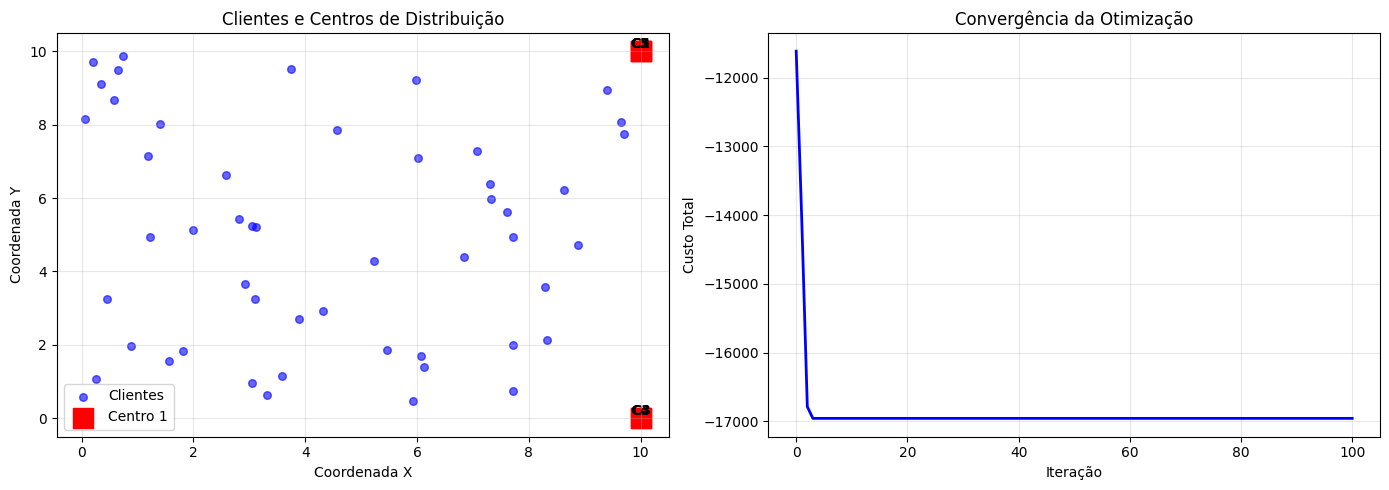

In [ ]:
"""
MISSÃO 3: OTIMIZAÇÃO LOGÍSTICA
Problema: Encontrar a localização de 5 centros de distribuição
que minimiza o custo de entrega para 50 clientes.
"""

import numpy as np
import matplotlib.pyplot as plt
import random
import time

# ==================== CONFIGURAÇÕES ====================
NUM_CLIENTES = 50
NUM_CENTROS = 5
NUM_PARTICULAS = 30
ITERACOES = 100
W = 0.7
C1 = 1.8
C2 = 1.8
LIMITE = 10  # Coordenadas de 0 a 10

# ==================== GERAR DADOS ====================
np.random.seed(42)
clientes = np.random.rand(NUM_CLIENTES, 2) * LIMITE
demandas = np.random.randint(1, 100, NUM_CLIENTES)

print("=" * 60)
print(" OPTIMUS TECH - LOGÍSTICA INTELIGENTE")
print("=" * 60)
print(f"\n DADOS DO PROBLEMA:")
print(f"   - {NUM_CLIENTES} clientes")
print(f"   - {NUM_CENTROS} centros de distribuição")
print(f"   - Demanda média: {np.mean(demandas):.1f} unidades")

# ==================== FUNÇÃO OBJETIVO ====================
def fitness(posicoes_centros):
    """
    Calcula o custo total de entrega.

    posicoes_centros: array de 10 elementos [x1,y1,x2,y2,...,x5,y5]
    Retorna: -custo_total (maximização)
    """
    # TODO 1: Converter para lista de centros
    centros = []
    for i in range(NUM_CENTROS):
        centros.append([posicoes_centros[2*i], posicoes_centros[2*i+1]])

    custo_total = 0

    # Para cada cliente
    for cliente, demanda in zip(clientes, demandas):
        # TODO 2: Encontrar o centro mais próximo
        distancias = [np.sqrt((c[0] - cliente[0])**2 + (c[1] - cliente[1])**2)
                      for c in centros]

        # TODO 3: Calcular distância ao centro mais próximo
        distancia_minima = min(distancias)

        # TODO 4: Adicionar ao custo total
        custo_total += distancia_minima * demanda

    # Retornar negativo (maximização)
    return -custo_total

# ==================== PSO COMPLETO ====================

# TODO 5: Criar uma partícula (10 dimensões)
def criar_particula():
    dim = NUM_CENTROS * 2
    posicao = np.random.uniform(0, LIMITE, dim)
    velocidade = np.random.uniform(-0.5, 0.5, dim)
    fit = fitness(posicao)

    particula = {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }
    return particula

# TODO 6: Atualizar velocidade (10 dimensões)
def atualizar_velocidade(particula, gBest_pos):
    dim = NUM_CENTROS * 2
    r1 = np.random.random(dim)
    r2 = np.random.random(dim)

    nova_velocidade = (W * particula['velocidade']
                        + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
                        + C2 * r2 * (gBest_pos - particula['posicao']))
    return nova_velocidade

# TODO 7: Atualizar posição (10 dimensões) com limites
def atualizar_posicao(particula):
    nova_posicao = particula['posicao'] + particula['velocidade']
    nova_posicao = np.clip(nova_posicao, 0, LIMITE)
    return nova_posicao

# ==================== EXECUTAR ====================
def executar_pso():
    # Inicializar
    enxame = []
    for _ in range(NUM_PARTICULAS):
        enxame.append(criar_particula())

    # Encontrar gBest
    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = [gBest_fit]

    print("\n OTIMIZANDO...")
    start_time = time.time()

    for iteracao in range(ITERACOES):
        for p in enxame:
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)
            p['fitness'] = fitness(p['posicao'])

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

        if (iteracao + 1) % 20 == 0:
            print(f"  Iteração {iteracao+1:3d}: Custo = {-gBest_fit:.2f}")

    execution_time = time.time() - start_time

    return gBest_pos, gBest_fit, historico, execution_time

# ==================== RESULTADOS ====================
best_pos, best_fit, historico, exec_time = executar_pso()

# Converter melhor posição para centros
centros = []
for i in range(NUM_CENTROS):
    centros.append([best_pos[2*i], best_pos[2*i+1]])

# Converter melhor posição para centros
centros = []
for i in range(NUM_CENTROS):
    centros.append([best_pos[2*i], best_pos[2*i+1]])

print(f"\n RESULTADO FINAL:")
print(f"   Tempo de execução: {exec_time:.2f} segundos")
print(f"   Custo total: {abs(best_fit):.2f}")
print(f"   Melhor custo possível: 0.00")
print(f"   Centros de distribuição:")
for i, centro in enumerate(centros):
    print(f"      Centro {i+1}: ({centro[0]:.2f}, {centro[1]:.2f})")

# ==================== VISUALIZAÇÃO ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de clientes e centros
ax1.scatter(clientes[:, 0], clientes[:, 1], c='blue', s=30, alpha=0.6, label='Clientes')
for i, centro in enumerate(centros):
    ax1.scatter(centro[0], centro[1], c='red', s=200, marker='s',
               label=f'Centro {i+1}' if i == 0 else "")
    ax1.annotate(f'C{i+1}', (centro[0], centro[1]), fontsize=10,
                ha='center', va='bottom', weight='bold')

ax1.set_xlabel('Coordenada X')
ax1.set_ylabel('Coordenada Y')
ax1.set_title('Clientes e Centros de Distribuição')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Convergência
ax2.plot(historico, 'b-', linewidth=2)
ax2.set_xlabel('Iteração')
ax2.set_ylabel('Custo Total')
ax2.set_title('Convergência da Otimização')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Missão 4 – Otimização de Parâmetros

Objetivo: testar combinações diferentes de w, c1, c2 e número de partículas no problema da Missão 3, pra entender o efeito de cada parâmetro no resultado. Esse código já veio pronto do professor, o trabalho aqui é rodar e analisar.

 EXPERIMENTOS COM PARÂMETROS DO PSO

 Experimento: Padrão
   Parâmetros: w=0.7, c1=1.8, c2=1.8, partículas=30


   Custo médio: 16764.48 ± 1317.48

 Experimento: Inércia Alta
   Parâmetros: w=0.9, c1=1.8, c2=1.8, partículas=30


   Custo médio: 19262.97 ± 1918.66

 Experimento: Inércia Baixa
   Parâmetros: w=0.5, c1=1.8, c2=1.8, partículas=30


   Custo médio: 16386.38 ± 1818.45

 Experimento: Cognitivo Alto
   Parâmetros: w=0.7, c1=2.5, c2=1.8, partículas=30


   Custo médio: 16570.90 ± 2672.41

 Experimento: Social Alto
   Parâmetros: w=0.7, c1=1.8, c2=2.5, partículas=30


   Custo médio: 15812.90 ± 1636.68

 Experimento: Mais Partículas
   Parâmetros: w=0.7, c1=1.8, c2=1.8, partículas=60


   Custo médio: 20164.06 ± 1664.27

 ANÁLISE DOS RESULTADOS

| Experimento        | Custo Médio | Melhor Custo | Pior Custo  |
|--------------------|-------------|--------------|-------------|
| Padrão             |   16764.48 |     19025.98 |    15443.17 |
| Inércia Alta       |   19262.97 |     21460.47 |    16955.05 |
| Inércia Baixa      |   16386.38 |     19025.98 |    13552.66 |
| Cognitivo Alto     |   16570.90 |     21460.47 |    13552.66 |
| Social Alto        |   15812.90 |     16955.05 |    12756.20 |
| Mais Partículas    |   20164.06 |     21460.47 |    16955.05 |


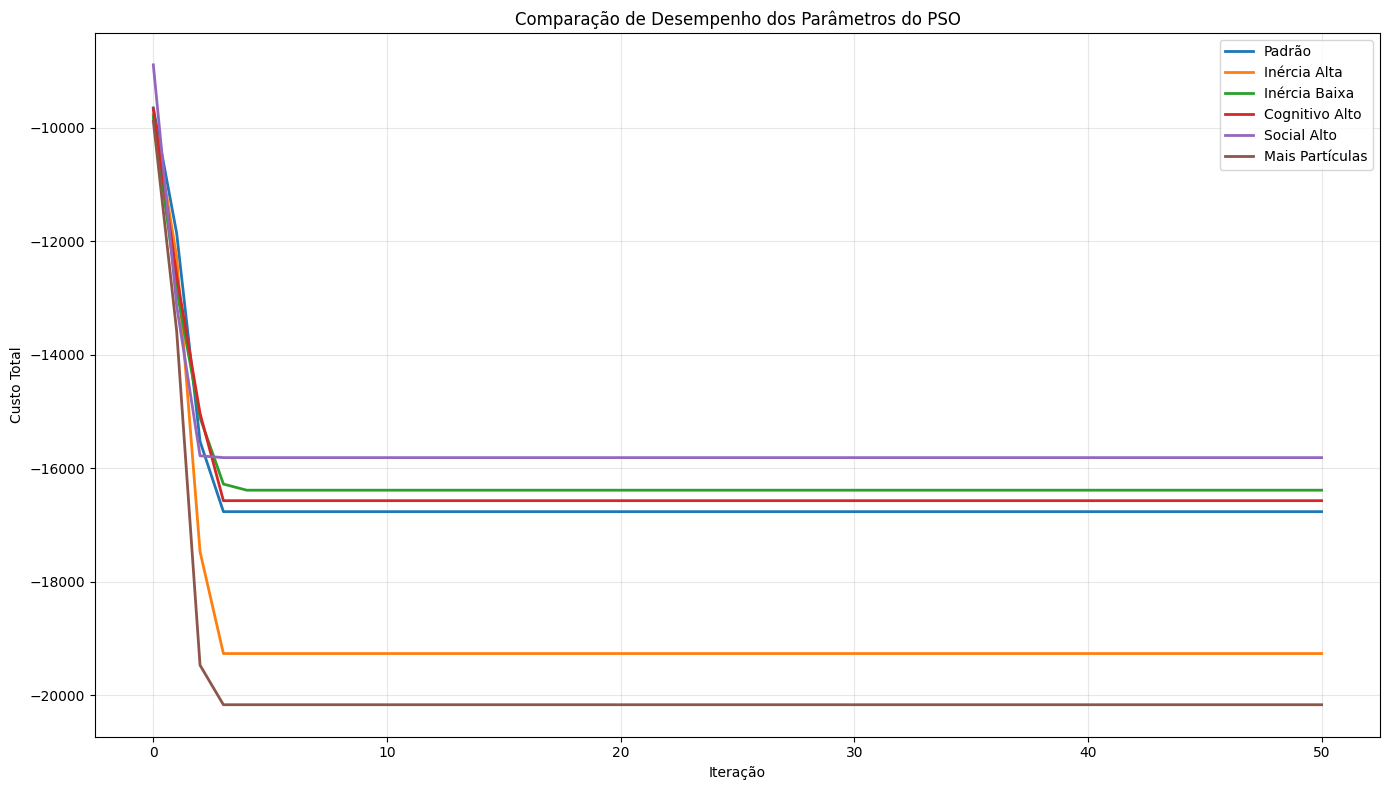


 ANÁLISE E CONCLUSÕES

1. Qual configuração obteve o MELHOR resultado?
   → Social Alto

2. Qual configuração obteve o PIOR resultado?
   → Mais Partículas

3. O que você observou sobre o efeito de:
   - Inércia (w):
   - Cognitivo (c1):
   - Social (c2):
   - Número de partículas:

4. Qual configuração você recomenda para este problema? Por quê?


In [ ]:
"""
MISSÃO 4: OTIMIZAÇÃO DOS PARÂMETROS DO PSO
Objetivo: Encontrar a melhor combinação de parâmetros para o problema logístico
"""

import numpy as np
import matplotlib.pyplot as plt
import random
import time

# ==================== CONFIGURAÇÕES ====================
# Parâmetros base
BASE_PARAMS = {
    'num_particulas': 30,
    'iteracoes': 50,
    'w': 0.7,
    'c1': 1.8,
    'c2': 1.8,
    'limite': 10,
    'num_centros': 5,
    'num_clientes': 50
}

# Experimentos a serem realizados
EXPERIMENTOS = [
    {'nome': 'Padrão', 'params': BASE_PARAMS.copy()},
    {'nome': 'Inércia Alta', 'params': {**BASE_PARAMS, 'w': 0.9}},
    {'nome': 'Inércia Baixa', 'params': {**BASE_PARAMS, 'w': 0.5}},
    {'nome': 'Cognitivo Alto', 'params': {**BASE_PARAMS, 'c1': 2.5}},
    {'nome': 'Social Alto', 'params': {**BASE_PARAMS, 'c2': 2.5}},
    {'nome': 'Mais Partículas', 'params': {**BASE_PARAMS, 'num_particulas': 60}},
]

# ==================== GERAR DADOS ====================
np.random.seed(42)
clientes = np.random.rand(BASE_PARAMS['num_clientes'], 2) * BASE_PARAMS['limite']
demandas = np.random.randint(1, 100, BASE_PARAMS['num_clientes'])

# ==================== FUNÇÃO FITNESS ====================
def fitness(posicoes_centros, clientes, demandas, num_centros):
    centros = [posicoes_centros[2*i:2*i+2] for i in range(num_centros)]
    custo_total = 0

    for cliente, demanda in zip(clientes, demandas):
        distancias = [np.sqrt((c[0] - cliente[0])**2 + (c[1] - cliente[1])**2)
                      for c in centros]
        custo_total += min(distancias) * demanda

    return -custo_total

# ==================== PSO ====================
def executar_pso(params, clientes, demandas):
    num_particulas = params['num_particulas']
    iteracoes = params['iteracoes']
    w = params['w']
    c1 = params['c1']
    c2 = params['c2']
    limite = params['limite']
    num_centros = params['num_centros']
    dim = num_centros * 2

    # Inicializar
    enxame = []
    for _ in range(num_particulas):
        posicao = np.random.uniform(0, limite, dim)
        velocidade = np.random.uniform(-0.5, 0.5, dim)
        fit = fitness(posicao, clientes, demandas, num_centros)
        enxame.append({
            'posicao': posicao,
            'velocidade': velocidade,
            'fitness': fit,
            'pBest_pos': posicao.copy(),
            'pBest_fit': fit
        })

    # gBest
    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = [gBest_fit]

    for _ in range(iteracoes):
        for p in enxame:
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)

            p['velocidade'] = w * p['velocidade'] + \
                             c1 * r1 * (p['pBest_pos'] - p['posicao']) + \
                             c2 * r2 * (gBest_pos - p['posicao'])

            p['posicao'] = np.clip(p['posicao'] + p['velocidade'], 0, limite)
            p['fitness'] = fitness(p['posicao'], clientes, demandas, num_centros)

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

    return gBest_fit, historico

# ==================== EXECUTAR EXPERIMENTOS ====================
print("=" * 60)
print(" EXPERIMENTOS COM PARÂMETROS DO PSO")
print("=" * 60)

resultados = {}

for exp in EXPERIMENTOS:
    print(f"\n Experimento: {exp['nome']}")
    print(f"   Parâmetros: w={exp['params']['w']}, c1={exp['params']['c1']}, "
          f"c2={exp['params']['c2']}, partículas={exp['params']['num_particulas']}")

    # Executar múltiplas vezes para ter média
    execucoes = 5
    custos = []
    historicos = []

    for i in range(execucoes):
        custo_final, historico = executar_pso(exp['params'], clientes, demandas)
        custos.append(custo_final)
        historicos.append(historico)

    resultados[exp['nome']] = {
        'custo_medio': -np.mean(custos),
        'custo_std': np.std(custos),
        'melhor_custo': -min(custos),
        'pior_custo': -max(custos),
        'historico': np.mean(historicos, axis=0)
    }

    print(f"   Custo médio: {resultados[exp['nome']]['custo_medio']:.2f} ± "
          f"{resultados[exp['nome']]['custo_std']:.2f}")

# ==================== ANÁLISE DOS RESULTADOS ====================
print("\n" + "=" * 60)
print(" ANÁLISE DOS RESULTADOS")
print("=" * 60)

print("\n| Experimento        | Custo Médio | Melhor Custo | Pior Custo  |")
print("|--------------------|-------------|--------------|-------------|")
for nome, data in resultados.items():
    print(f"| {nome:<18} | {data['custo_medio']:10.2f} | {data['melhor_custo']:12.2f} | "
          f"{data['pior_custo']:11.2f} |")

# ==================== VISUALIZAÇÃO ====================
plt.figure(figsize=(14, 8))

for nome, data in resultados.items():
    plt.plot(data['historico'], linewidth=2, label=nome)

plt.xlabel('Iteração')
plt.ylabel('Custo Total')
plt.title('Comparação de Desempenho dos Parâmetros do PSO')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== RELATÓRIO ====================
# RESPONDAM AS QUESTÕES ABAIXO:

print("\n" + "=" * 60)
print(" ANÁLISE E CONCLUSÕES")
print("=" * 60)
print("\n1. Qual configuração obteve o MELHOR resultado?")
print("   →", min(resultados.items(), key=lambda x: x[1]['custo_medio'])[0])

print("\n2. Qual configuração obteve o PIOR resultado?")
print("   →", max(resultados.items(), key=lambda x: x[1]['custo_medio'])[0])

print("\n3. O que você observou sobre o efeito de:")
print("   - Inércia (w):")
print("   - Cognitivo (c1):")
print("   - Social (c2):")
print("   - Número de partículas:")

print("\n4. Qual configuração você recomenda para este problema? Por quê?")